In [22]:
import numpy as np
from tifffile import TiffFile, imwrite, TiffWriter
from microaligner import FeatureRegistrator, transform_img_with_tmat, OptFlowRegistrator, Warper 
import tifffile as tif


In [3]:
!pip3 list

Package                  Version
------------------------ -----------
aiobotocore              2.5.4
aiohappyeyeballs         2.4.3
aiohttp                  3.10.10
aioitertools             0.12.0
aiosignal                1.3.1
anndata                  0.10.2
archspec                 0.2.3
array_api_compat         1.9.1
asciitree                0.3.3
attrs                    24.2.0
behave                   1.2.6
boltons                  24.0.0
botocore                 1.31.17
Brotli                   1.1.0
certifi                  2024.8.30
cffi                     1.17.1
charset-normalizer       3.4.0
click                    8.1.7
cloudpickle              3.1.0
colorama                 0.4.6
colorcet                 3.1.0
conda                    24.9.0
conda-libmamba-solver    24.9.0
conda-package-handling   2.4.0
conda_package_streaming  0.11.0
constants                0.6.0
contourpy                1.3.0
crcmod                   1.7
cycler                   0.12.1
dask            

In [24]:
def OpenTiff(file_path):
    with TiffFile(file_path) as fh:
        img_data = fh.asarray()
        metadata = fh.ome_metadata
    return img_data, metadata

def GetScaleCoefTrMat(shape_big_img, shape_small_img):
    scale = np.max(shape_big_img)/np.min(shape_small_img)
    TrMat = np.array([[scale, 0, 0], [0, scale, 0]])
    return TrMat




def FeatRegistration(img1, img2):
    freg = FeatureRegistrator()
    print('a')
    freg.ref_img = img1
    freg.mov_img = img2
    print('b')
    freg.num_iterations = 3
    freg.use_full_res_img = False
    freg.tile_size = 5000
    #freg._factors = [16,8,4,2] #pyramid levels               
    freg.num_pyr_lvl = 5
    freg.use_dog = True
    print('c')
    transformation_matrix = freg.register()
    print('d')
    img2_reg = transform_img_with_tmat(img2, img2.shape, transformation_matrix)
    return img2_reg, transformation_matrix


def MergeAndSave(img_1ch, img_3ch, Name, ome_meta):
    metadata={
         'axes': 'CYX',
         'PhysicalSizeX': 0.2125,
         'PhysicalSizeXUnit': 'µm',
         'PhysicalSizeY': 0.2125,
         'PhysicalSizeYUnit': 'µm',
         'Channel': {'Name': ['Xenium_DAPI', 'Fluo_DAPI', 'Nestin', 'GFAP']},
     }
    img = np.zeros((4, img_1ch.shape[0], img_1ch.shape[1]), dtype = img_1ch.dtype)
    img[0] = img_1ch; img[1:] = img_3ch
    FullName = Name + '.tif'
    tif.imwrite(FullName, img, metadata = metadata, bigtiff = True, compression='zlib')

In [25]:
img_HE = OpenTiff('/nfs/team283_imaging/0NDPI/AA_ASD_SFARI/Xenium HE/OB42638 - 2024-09-13 16.41.10.ndpi')[0]
img_HE.shape

(60416, 98304, 3)

In [12]:
img_X = OpenTiff('/nfs/team283_imaging/0XeniumExports/AA_ASD/20240611__114404__AA_ASD_Hs_foetal_brain_SFARI_7/output-XETG00272__0034200__Sob23-BRA-0-FFPE-5__20240611__114424/morphology_mip.ome.tif')[0]
img_X.shape

(40876, 54098)

In [23]:
img_X.dtype

dtype('uint16')

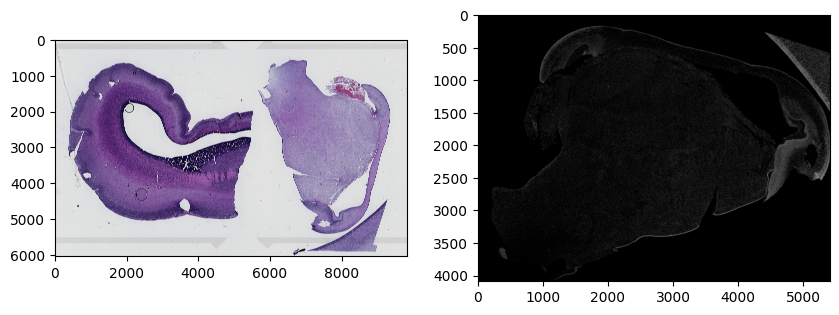

In [13]:
import matplotlib.pyplot as plt
#img_displ = bw1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))
ax1.imshow(img_HE[::10,::10,:])
ax2.imshow(img_X[::10,::10], cmap = 'gray')

(41304, 60416, 3)


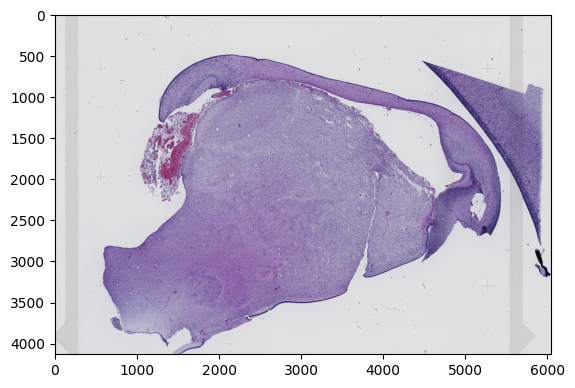

In [26]:
img_HE_crop = np.swapaxes(img_HE[:, 57000:,:], 0, 1)
img_HE_crop = np.flip(img_HE_crop, axis=0)
print(img_HE_crop.shape)
plt.imshow(img_HE_crop[::10,::10])

## Prepare two images - for the same size and "modality"

In [56]:
def prep_images_for_registration(img_1ch, img_3ch, contrast_coef = 1):
    xsize = np.max([img_1ch.shape[1], img_3ch.shape[1]])
    ysize = np.max([img_1ch.shape[0], img_3ch.shape[0]])
    
    img1 = np.zeros((ysize, xsize), dtype = img_3ch.dtype)
    img1_orig = np.zeros((ysize, xsize), dtype = img_1ch.dtype)
    
    img2 = np.zeros((ysize, xsize), dtype = img_3ch.dtype)
    img2_3ch = np.zeros((ysize, xsize), dtype = img_1ch.dtype)
    img2_3ch_orig = np.zeros((ysize, xsize,3), dtype = img_3ch.dtype)
    
    img1[:img_1ch.shape[0], :img_1ch.shape[1]] = np.clip(img_1ch/np.max(img_1ch)*255, 0, 50)
    img2[:img_3ch.shape[0], :img_3ch.shape[1]] = 255-np.mean(img_3ch, axis = 2)
    
    img1_orig[:img_1ch.shape[0], :img_1ch.shape[1]] = img_1ch
    img2_3ch_orig[:img_3ch.shape[0], :img_3ch.shape[1], :] = img_3ch
    
    return img1, img2, img1_orig, img2_3ch_orig

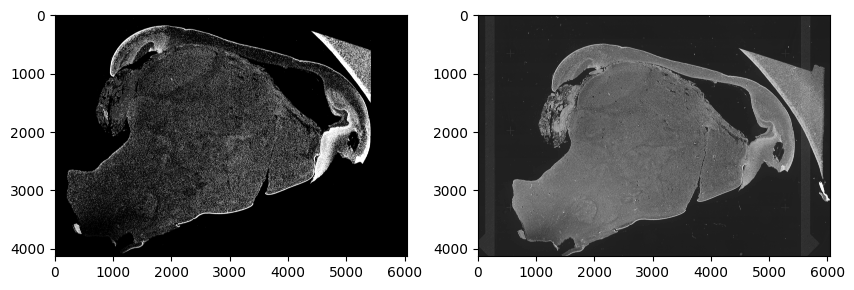

In [58]:
img1, img2, img1_orig, img2_orig = prep_images_for_registration(img_X, img_HE_crop)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))
ax1.imshow(img1[::10,::10], cmap = 'gray')
ax2.imshow(img2[::10,::10], cmap = 'gray')

## feature registration

a
b
c
Pyramid factor 32
    Iteration 1 / 3
    Good matches 11 / 5000
    MI score after: 0.0 | MI score before: 0.03023074895805382
    Worse alignment than before
    Iteration 2 / 3
    Good matches 10 / 5000
    MI score after: 0.0 | MI score before: 0.03023074895805382
    Worse alignment than before
    Iteration 3 / 3
    Good matches 10 / 5000
    MI score after: 0.0 | MI score before: 0.03023074895805382
    Worse alignment than before
Pyramid factor 16
    Iteration 1 / 3
    Good matches 13 / 5000
    MI score after: 0.10540195253298862 | MI score before: 0.04022407615066948
    Better alignment than before
    Iteration 2 / 3
    Good matches 11 / 5000
    MI score after: 0.015529771654103504 | MI score before: 0.10540195253298862
    Worse alignment than before
    Iteration 3 / 3
    Good matches 9 / 5000
    MI score after: 0.09771616373653423 | MI score before: 0.10540195253298862
    Worse alignment than before
Pyramid factor 8
    Iteration 1 / 3
    Good matches 8 /

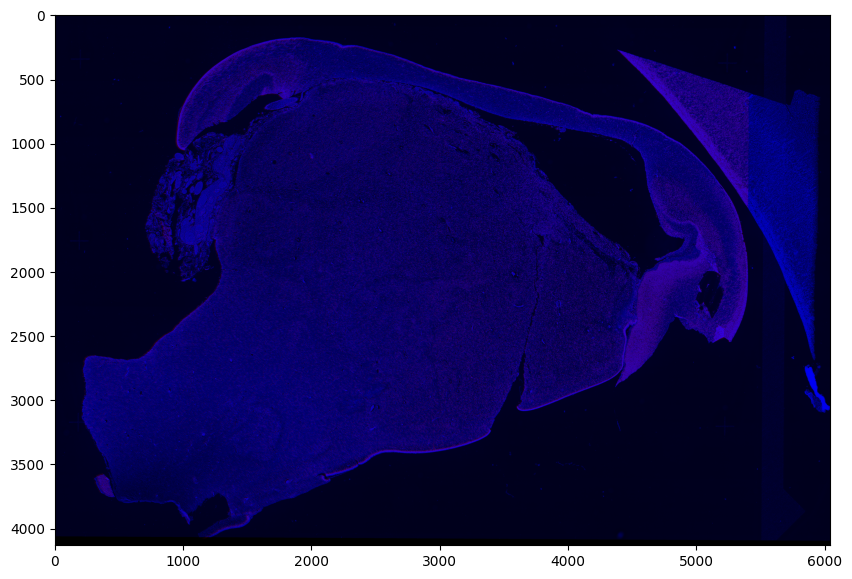

In [51]:
img2_reg, transformation_matrix = FeatRegistration(img1, img2)

composed_img = np.zeros((img2_reg.shape[0],img2_reg.shape[1],3), dtype = 'uint8') 
composed_img[:,:,0] = img1
composed_img[:,:,2] = img2_reg


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plt.imshow(composed_img[::10,::10])

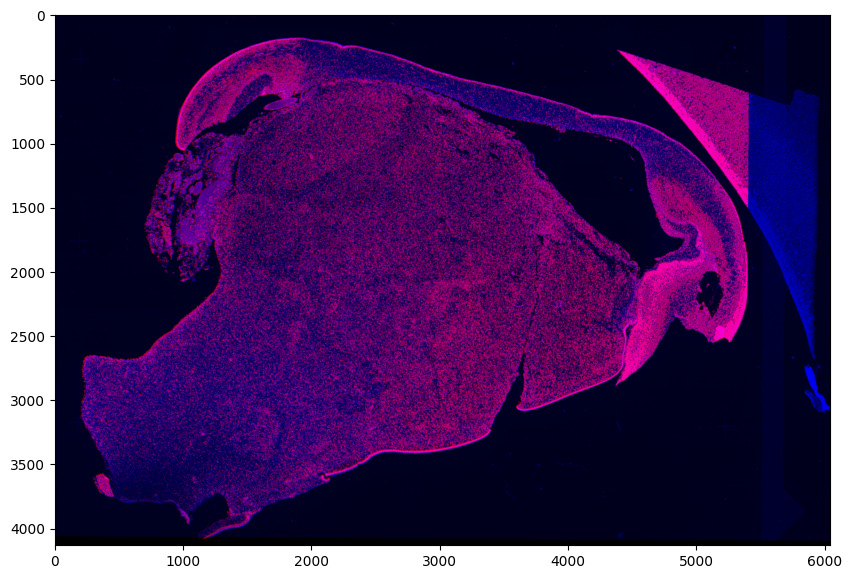

In [52]:
composed_img = np.zeros((img2_reg.shape[0],img2_reg.shape[1],3), dtype = 'uint8') 
composed_img[:,:,0] = img1*10
composed_img[:,:,2] = img2_reg


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plt.imshow(composed_img[::10,::10])

In [59]:
transformation_matrix

array([[ 1.07188692e+00, -6.12987566e-03, -3.93433614e+03],
       [ 6.12987566e-03,  1.07188692e+00, -3.66896871e+03]])

In [ ]:
array([[ 1.07188692e+00, -6.12987566e-03, -3.93433614e+03],
       [ 6.12987566e-03,  1.07188692e+00, -3.66896871e+03]])

## try registration from pystackreg - skip it

In [12]:
from pystackreg import StackReg
from skimage.transform import AffineTransform, warp

array([[1.3, 0. , 0. ],
       [0. , 1.3, 0. ]])

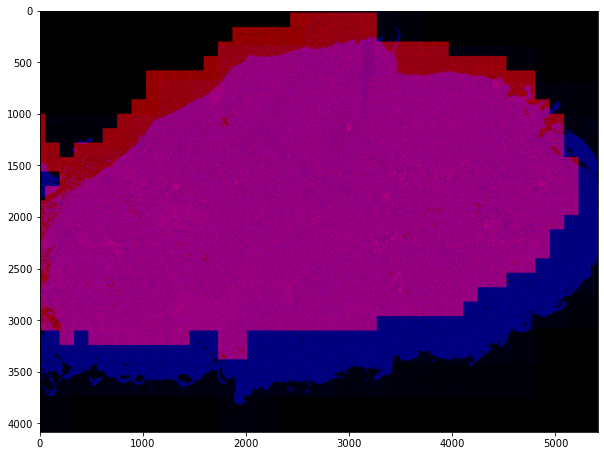

In [13]:
sr = StackReg(StackReg.AFFINE)
tmat= sr.register(img1, img2)
img2_reg = np.zeros_like(img2)
AT = AffineTransform(tmat)
img2_reg = warp(img2, AT, output_shape=img2_reg.shape, preserve_range=True).astype(img2.dtype)



composed_img = np.zeros((img2_reg.shape[0],img2_reg.shape[1],3), dtype = 'uint8') 
composed_img[:,:,0] = img1
composed_img[:,:,2] = img2_reg


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plt.imshow(composed_img[::10,::10])

## lets register 3ch image and save both images (separetely)

In [60]:
tif.imwrite('DAPI_Sob23-BRA-0-FFPE-5.tif', img1_orig, metadata = {'axes': 'YX', 'Channel': {'Name': ['DAPI']}})

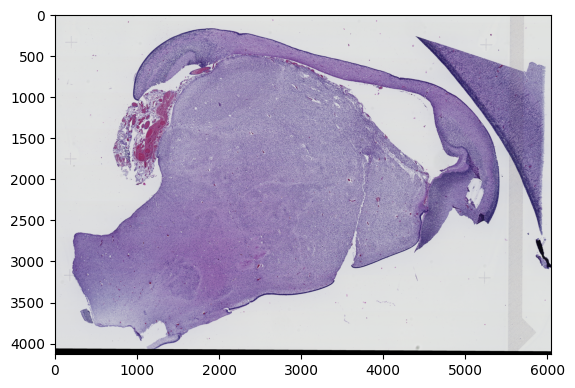

In [63]:
img2_reg_3ch = np.zeros_like(img2_orig)
for i in range(img2_orig.shape[2]):
    print(i)
    img2_reg_3ch[:,:,i] = transform_img_with_tmat(img2_orig[:,:,i], img2_orig[:,:,i].shape, transformation_matrix)

plt.imshow(img2_reg_3ch[::10, ::10])

In [70]:
#print(img2_reg_3ch.shape)
#img2_reg_3ch = np.swapaxes(img2_reg_3ch, 0,2)
#img2_reg_3ch = np.swapaxes(img2_reg_3ch, 1,2)
#print(img2_reg_3ch.shape)
tif.imwrite('HE_Sob23-BRA-0-FFPE-5.tif', img2_reg_3ch, metadata = {'axes': 'YXC'}, photometric = 'rgb')

## now lets pull original annotations

In [9]:
import omero
import numpy as np
import scanpy as sc
import pandas as pd
from tqdm import tqdm
from PIL import Image
from omero.gateway import BlitzGateway
from shapely import affinity,plotting
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
import logging
log = logging.getLogger(__name__)
import io


def collect_ROIs_from_OMERO(omero_username, omero_password, omero_host, omero_image_id):
    ROIs = []
    log.info(f"Connecting to OMERO at {omero_host}")
    with BlitzGateway(omero_username, omero_password, host=omero_host, secure=True) as conn:
        # search image
        log.info(f"Looking for ImageId {omero_image_id}")
        conn.SERVICE_OPTS.setOmeroGroup('-1')
        image = conn.getObject("Image", omero_image_id)
        # set group for image
        log.info(f"Found image id={image.id} name='{image.name}'")
        log.info(f"Found image in group id={image.details.group.id.val} name='{image.details.group.name.val}'")
        
        log.info(f"Storing rendered thumbnail in memory for QC")
        img_data = image.getThumbnail() #tiny preview image
        rendered_thumb = Image.open(io.BytesIO(img_data))
        
        group_id = image.details.group.id #check group id
        conn.setGroupForSession(group_id.val)
        # get image ROIs
        roi_service = conn.getRoiService()
        log.info("Retrieving ROIs")
        result = roi_service.findByImage(image.id, None)
        #result has property roi - for one given image id
        for roi in result.rois:
            try:
                primary_shape = roi.getPrimaryShape()
                name = primary_shape.getTextValue().val
                #, separates x and y and  space separates points
                points = [(lambda xy : list(map(float,xy.split(","))))(xy) for xy in primary_shape.getPoints().val.split(" ")]
                ROIs.append({
                    "name": name,
                    "points": points
                })
                log.debug(f"Found ROI id={roi.id.val} name='{name}' type={primary_shape.__class__.__name__}")
            except:
                pass
    log.info(f"Found {len(ROIs)} ROIs in total")
    return ROIs, image

In [10]:
omero_username = 'sm57'
omero_password = 'CnfcVfrfhxer19'
omero_host = "wsi-omero-prod-02.internal.sanger.ac.uk"
omero_image_id = 69106

In [141]:
ROIs_orig, image = collect_ROIs_from_OMERO(omero_username, omero_password, omero_host, omero_image_id)

In [142]:
ROIs_orig

[{'name': 'red nucleus',
  'points': [[66170.0, 19649.13],
   [67041.27, 18046.96],
   [65519.41, 16525.03],
   [64191.33, 16581.3],
   [63177.96, 17026.13],
   [62490.34, 18819.34],
   [63079.14, 20135.44],
   [65056.94, 20586.79],
   [66510.54, 20248.11]]},
 {'name': 'midbrain',
  'points': [[74872.52, 15857.97],
   [72832.42, 18202.76],
   [71992.83, 20202.5],
   [68971.37, 22657.34],
   [64615.55, 23794.66],
   [61509.5, 23827.34],
   [60219.84, 17279.07],
   [60259.25, 11896.96],
   [60816.25, 8315.61],
   [67847.75, 7842.71],
   [68639.04, 8800.28]]},
 {'name': 'centromedian nucleus',
  'points': [[75680.75, 33339.51],
   [75928.14, 31661.92],
   [75565.3, 30033.44],
   [75756.78, 27551.14],
   [74879.3, 25523.4],
   [74023.53, 24913.51],
   [72479.99, 24522.36],
   [70372.43, 24707.22],
   [69300.31, 26663.96],
   [68130.9, 27428.01],
   [66516.63, 27400.94],
   [65322.1, 28249.12],
   [66094.16, 30900.14],
   [67686.45, 33002.91],
   [69764.4, 31988.42],
   [70564.88, 31014.73]

(58753.85999999999, 91005.42, 47563.4645, 5951.2455)

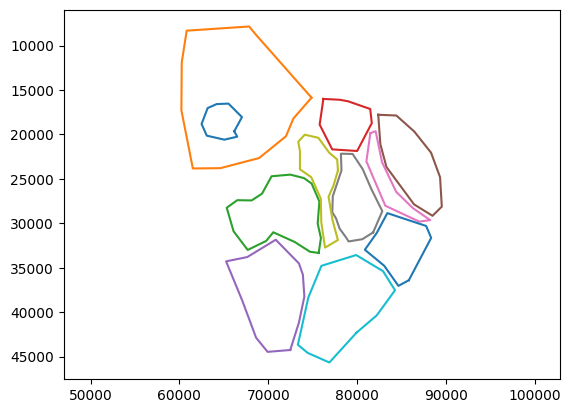

In [143]:
## original polygons
ROIs = ROIs_orig.copy()
import matplotlib.pyplot as plt
for roi in ROIs:
    #polygon = rotate_flip_polygon(Polygon(roi['points']), [image.getSizeY()/2, image.getSizeX()/2], 0, flipX=False, flipY=False)
    polygon = Polygon(roi['points'])
    x,y = polygon.exterior.xy
    plt.plot(x,y)
plt.gca().invert_yaxis()
plt.axis('equal')

In [144]:
## now lets play with ROIs
#1. I cropped an image, so I need to reduce position in x by this amount
offset_x = 57000
for roi in ROIs:
    roi['points'] = [[sublist[0] - offset_x] + sublist[1:] for sublist in roi['points']]
ROIs

[{'name': 'red nucleus',
  'points': [[9170.0, 19649.13],
   [10041.270000000004, 18046.96],
   [8519.410000000003, 16525.03],
   [7191.330000000002, 16581.3],
   [6177.959999999999, 17026.13],
   [5490.3399999999965, 18819.34],
   [6079.139999999999, 20135.44],
   [8056.940000000002, 20586.79],
   [9510.539999999994, 20248.11]]},
 {'name': 'midbrain',
  'points': [[17872.520000000004, 15857.97],
   [15832.419999999998, 18202.76],
   [14992.830000000002, 20202.5],
   [11971.369999999995, 22657.34],
   [7615.550000000003, 23794.66],
   [4509.5, 23827.34],
   [3219.8399999999965, 17279.07],
   [3259.25, 11896.96],
   [3816.25, 8315.61],
   [10847.75, 7842.71],
   [11639.039999999994, 8800.28]]},
 {'name': 'centromedian nucleus',
  'points': [[18680.75, 33339.51],
   [18928.14, 31661.92],
   [18565.300000000003, 30033.44],
   [18756.78, 27551.14],
   [17879.300000000003, 25523.4],
   [17023.53, 24913.51],
   [15479.990000000005, 24522.36],
   [13372.429999999993, 24707.22],
   [12300.3099

(1753.859999999996, 34005.420000000006, 47563.4645, 5951.2455)

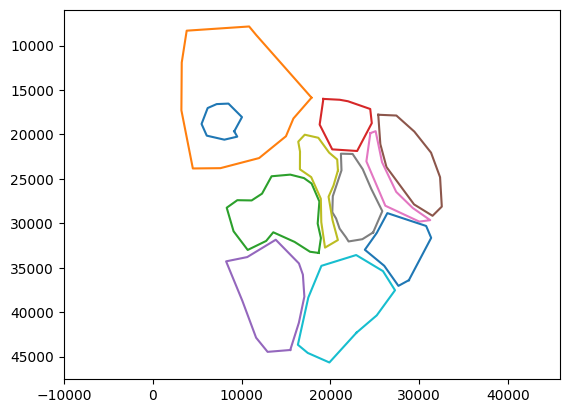

In [145]:
import matplotlib.pyplot as plt
for roi in ROIs:
    #polygon = rotate_flip_polygon(Polygon(roi['points']), [image.getSizeY()/2, image.getSizeX()/2], 0, flipX=False, flipY=False)
    polygon = Polygon(roi['points'])
    x,y = polygon.exterior.xy
    plt.plot(x,y)
plt.gca().invert_yaxis()
plt.axis('equal')

In [146]:
#2. hopefully the image size for HE remnained the same in both axes - so nothing has to be added or removed
#3. then I transposed (changed x to y)
for roi in ROIs:
    roi['points'] = [sublist[1:] + sublist[:1] for sublist in roi['points']]
ROIs

[{'name': 'red nucleus',
  'points': [[19649.13, 9170.0],
   [18046.96, 10041.270000000004],
   [16525.03, 8519.410000000003],
   [16581.3, 7191.330000000002],
   [17026.13, 6177.959999999999],
   [18819.34, 5490.3399999999965],
   [20135.44, 6079.139999999999],
   [20586.79, 8056.940000000002],
   [20248.11, 9510.539999999994]]},
 {'name': 'midbrain',
  'points': [[15857.97, 17872.520000000004],
   [18202.76, 15832.419999999998],
   [20202.5, 14992.830000000002],
   [22657.34, 11971.369999999995],
   [23794.66, 7615.550000000003],
   [23827.34, 4509.5],
   [17279.07, 3219.8399999999965],
   [11896.96, 3259.25],
   [8315.61, 3816.25],
   [7842.71, 10847.75],
   [8800.28, 11639.039999999994]]},
 {'name': 'centromedian nucleus',
  'points': [[33339.51, 18680.75],
   [31661.92, 18928.14],
   [30033.44, 18565.300000000003],
   [27551.14, 18756.78],
   [25523.4, 17879.300000000003],
   [24913.51, 17023.53],
   [24522.36, 15479.990000000005],
   [24707.22, 13372.429999999993],
   [26663.96, 

(5951.2455, 47563.4645, 34005.420000000006, 1753.859999999996)

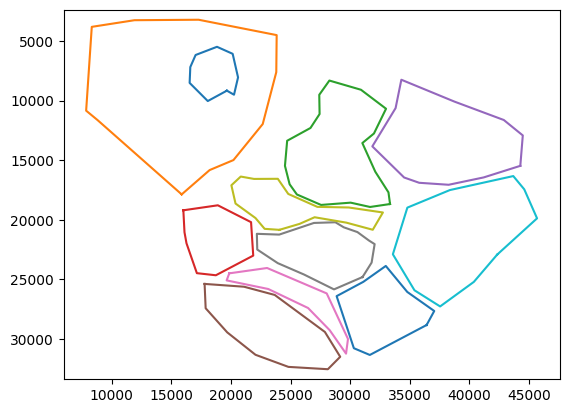

In [147]:
for roi in ROIs:
    #polygon = rotate_flip_polygon(Polygon(roi['points']), [image.getSizeY()/2, image.getSizeX()/2], 0, flipX=False, flipY=False)
    polygon = Polygon(roi['points'])
    x,y = polygon.exterior.xy
    plt.plot(x,y)
plt.gca().invert_yaxis()
plt.axis('equal')

In [148]:
#4. now I flipped y 
sizey = 41304
for roi in ROIs:
    roi['points'] = [sublist[:1] + [sizey-sublist[1]] for sublist in roi['points']]
ROIs

[{'name': 'red nucleus',
  'points': [[19649.13, 32134.0],
   [18046.96, 31262.729999999996],
   [16525.03, 32784.59],
   [16581.3, 34112.67],
   [17026.13, 35126.04],
   [18819.34, 35813.66],
   [20135.44, 35224.86],
   [20586.79, 33247.06],
   [20248.11, 31793.460000000006]]},
 {'name': 'midbrain',
  'points': [[15857.97, 23431.479999999996],
   [18202.76, 25471.58],
   [20202.5, 26311.17],
   [22657.34, 29332.630000000005],
   [23794.66, 33688.45],
   [23827.34, 36794.5],
   [17279.07, 38084.16],
   [11896.96, 38044.75],
   [8315.61, 37487.75],
   [7842.71, 30456.25],
   [8800.28, 29664.960000000006]]},
 {'name': 'centromedian nucleus',
  'points': [[33339.51, 22623.25],
   [31661.92, 22375.86],
   [30033.44, 22738.699999999997],
   [27551.14, 22547.22],
   [25523.4, 23424.699999999997],
   [24913.51, 24280.47],
   [24522.36, 25824.009999999995],
   [24707.22, 27931.570000000007],
   [26663.96, 29003.690000000002],
   [27428.01, 30173.100000000006],
   [27400.94, 31787.369999999995]

(5951.2455, 47563.4645, 39550.14000000001, 7298.579999999997)

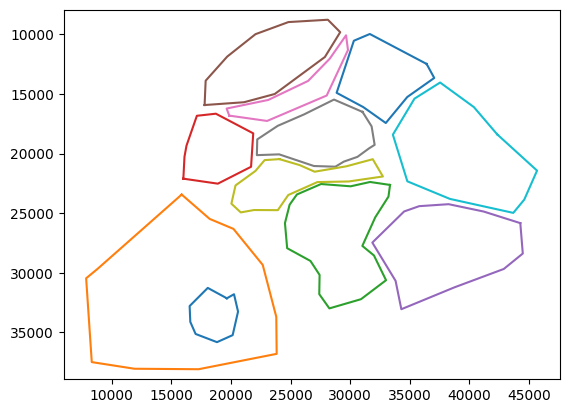

In [110]:
for roi in ROIs:
    #polygon = rotate_flip_polygon(Polygon(roi['points']), [image.getSizeY()/2, image.getSizeX()/2], 0, flipX=False, flipY=False)
    polygon = Polygon(roi['points'])
    x,y = polygon.exterior.xy
    plt.plot(x,y)
plt.gca().invert_yaxis()
plt.axis('equal')

In [149]:
# well done Stas! now you just need apply transformation matrix to each polygon! (basically spots)
trans_mat = np.array([[ 1.07188692e+00, -6.12987566e-03, -3.93433614e+03],
                   [ 6.12987566e-03,  1.07188692e+00, -3.66896871e+03]])
for roi in ROIs:
    #polygon = Polygon(roi['points'])
    points_list = roi['points']
    for i in range(len(points_list)):
        print(i)
        x = points_list[i][0]; y = points_list[i][1];
        xy = np.array([x, y])
        #xy = np.transpose(xy)
        trans_mat2 = np.transpose(trans_mat)
        print(xy.shape)
        print(trans_mat2.shape)
        xy1 = np.matmul(trans_mat2, xy)
        roi['points'][i] = [xy1[0], xy1[1]]

0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3, 2)
4
(2,)
(3, 2)
5
(2,)
(3, 2)
6
(2,)
(3, 2)
7
(2,)
(3, 2)
8
(2,)
(3, 2)
0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3, 2)
4
(2,)
(3, 2)
5
(2,)
(3, 2)
6
(2,)
(3, 2)
7
(2,)
(3, 2)
8
(2,)
(3, 2)
9
(2,)
(3, 2)
10
(2,)
(3, 2)
0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3, 2)
4
(2,)
(3, 2)
5
(2,)
(3, 2)
6
(2,)
(3, 2)
7
(2,)
(3, 2)
8
(2,)
(3, 2)
9
(2,)
(3, 2)
10
(2,)
(3, 2)
11
(2,)
(3, 2)
12
(2,)
(3, 2)
13
(2,)
(3, 2)
14
(2,)
(3, 2)
15
(2,)
(3, 2)
16
(2,)
(3, 2)
17
(2,)
(3, 2)
0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3, 2)
4
(2,)
(3, 2)
5
(2,)
(3, 2)
6
(2,)
(3, 2)
7
(2,)
(3, 2)
0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3, 2)
4
(2,)
(3, 2)
5
(2,)
(3, 2)
6
(2,)
(3, 2)
7
(2,)
(3, 2)
8
(2,)
(3, 2)
9
(2,)
(3, 2)
10
(2,)
(3, 2)
0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3, 2)
4
(2,)
(3, 2)
5
(2,)
(3, 2)
6
(2,)
(3, 2)
7
(2,)
(3, 2)
8
(2,)
(3, 2)
9
(2,)
(3, 2)
0
(2,)
(3, 2)
1
(2,)
(3, 2)
2
(2,)
(3, 2)
3
(2,)
(3,

(6568.5242589411255, 51111.19898454405, 42290.68276296234, 7647.53905425977)

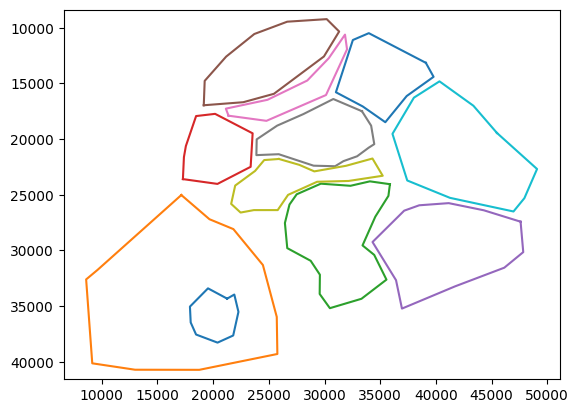

In [150]:
for roi in ROIs:
    #polygon = rotate_flip_polygon(Polygon(roi['points']), [image.getSizeY()/2, image.getSizeX()/2], 0, flipX=False, flipY=False)
    polygon = Polygon(roi['points'])
    x,y = polygon.exterior.xy
    plt.plot(x,y)
plt.gca().invert_yaxis()
plt.axis('equal')

## now I will assign cells to segmentation, and save it as csv

In [153]:
segmentation_csv = pd.read_csv('/nfs/team283_imaging/0XeniumExports/AA_ASD/20240611__114404__AA_ASD_Hs_foetal_brain_SFARI_7/output-XETG00272__0034200__Sob23-BRA-0-FFPE-5__20240611__114424/cells.csv.gz')
segmentation_csv

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area
0,aaaacdhh-1,839.702576,7007.010254,403,0,0,0,0,403,430.790641,51.523283
1,aaaacdil-1,843.805420,7026.302734,109,0,0,0,0,109,193.313913,26.687345
2,aaaanmme-1,831.943176,7025.638672,333,0,0,0,0,333,349.238450,40.640626
3,aaabdgeh-1,826.966248,7036.551758,233,0,0,0,0,233,251.068759,23.977970
4,aaabjdal-1,815.233826,7045.716797,224,0,0,0,0,224,314.693918,20.500938
...,...,...,...,...,...,...,...,...,...,...,...
279519,oijhiiag-1,9916.374023,6308.161621,16,0,0,0,0,16,937.488940,18.785001
279520,oijhmdca-1,10123.250000,6164.753906,2,0,0,0,0,2,94.286253,10.340782
279521,oijhmpin-1,10128.172852,6164.920410,2,0,0,0,0,2,114.832348,9.437657
279522,oijhpepg-1,10137.589844,6168.047363,4,0,0,0,0,4,478.746580,9.211875


In [159]:
def assign_cell_to_annotation(segmentation_table, ROIs, New_polygons, column_name_x, column_name_y, pixelsize):
    annotations = []
    log.info(f"Calling cell positions inside ROIs.")
    for barcode,row in tqdm(segmentation_table.iterrows(), total=segmentation_table.shape[0]):
        roi_annoation = []
        #for roi in ROIs:
        for roi, polygon in zip(ROIs, New_polygons):
            #print(roi)
            #polygon = Polygon(roi['points'])
            point = Point([row[column_name_x]/pixelsize,row[column_name_y]/pixelsize])
            if polygon.contains(point):
                roi_annoation.append(roi['name'])
        if not roi_annoation:
            roi_annoation = ["N-A"]
        # why ";".join? because some annotations may overlap for the same spot/barcode
        # in that case we capture all and merge them with ';' 
        annotations.append([ barcode, "; ".join(set(roi_annoation)) ])
    return annotations
def add_annotations_to_table(segmentation_table, annotations):
    ann_list = []
    for a in annotations:
        ann_list.append(a[1])
    segmentation_table['annotation'] = ann_list
    
    return segmentation_table

In [172]:
New_polygons = []
for roi in ROIs:
    New_polygons.append(Polygon(roi['points']))
annotations = assign_cell_to_annotation(segmentation_csv, ROIs, New_polygons, 'x_centroid', 'y_centroid', 0.2125)
annotations

100%|███████████████████████████████| 279524/279524 [02:40<00:00, 1742.06it/s]


[[0, 'N-A'],
 [1, 'N-A'],
 [2, 'N-A'],
 [3, 'N-A'],
 [4, 'N-A'],
 [5, 'N-A'],
 [6, 'N-A'],
 [7, 'N-A'],
 [8, 'N-A'],
 [9, 'N-A'],
 [10, 'N-A'],
 [11, 'N-A'],
 [12, 'N-A'],
 [13, 'N-A'],
 [14, 'N-A'],
 [15, 'N-A'],
 [16, 'N-A'],
 [17, 'N-A'],
 [18, 'N-A'],
 [19, 'N-A'],
 [20, 'N-A'],
 [21, 'N-A'],
 [22, 'N-A'],
 [23, 'N-A'],
 [24, 'N-A'],
 [25, 'N-A'],
 [26, 'N-A'],
 [27, 'N-A'],
 [28, 'N-A'],
 [29, 'N-A'],
 [30, 'N-A'],
 [31, 'N-A'],
 [32, 'N-A'],
 [33, 'N-A'],
 [34, 'N-A'],
 [35, 'N-A'],
 [36, 'N-A'],
 [37, 'N-A'],
 [38, 'N-A'],
 [39, 'N-A'],
 [40, 'N-A'],
 [41, 'N-A'],
 [42, 'N-A'],
 [43, 'N-A'],
 [44, 'N-A'],
 [45, 'N-A'],
 [46, 'N-A'],
 [47, 'N-A'],
 [48, 'N-A'],
 [49, 'N-A'],
 [50, 'N-A'],
 [51, 'N-A'],
 [52, 'N-A'],
 [53, 'N-A'],
 [54, 'N-A'],
 [55, 'N-A'],
 [56, 'N-A'],
 [57, 'N-A'],
 [58, 'N-A'],
 [59, 'N-A'],
 [60, 'N-A'],
 [61, 'N-A'],
 [62, 'N-A'],
 [63, 'N-A'],
 [64, 'N-A'],
 [65, 'N-A'],
 [66, 'N-A'],
 [67, 'N-A'],
 [68, 'N-A'],
 [69, 'N-A'],
 [70, 'N-A'],
 [71, 'N-A'],
 [

In [173]:
segmentation_table = add_annotations_to_table(segmentation_csv, annotations)
segmentation_table

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,annotation
0,aaaacdhh-1,839.702576,7007.010254,403,0,0,0,0,403,430.790641,51.523283,N-A
1,aaaacdil-1,843.805420,7026.302734,109,0,0,0,0,109,193.313913,26.687345,N-A
2,aaaanmme-1,831.943176,7025.638672,333,0,0,0,0,333,349.238450,40.640626,N-A
3,aaabdgeh-1,826.966248,7036.551758,233,0,0,0,0,233,251.068759,23.977970,N-A
4,aaabjdal-1,815.233826,7045.716797,224,0,0,0,0,224,314.693918,20.500938,N-A
...,...,...,...,...,...,...,...,...,...,...,...,...
279519,oijhiiag-1,9916.374023,6308.161621,16,0,0,0,0,16,937.488940,18.785001,dorsomedial nucleus
279520,oijhmdca-1,10123.250000,6164.753906,2,0,0,0,0,2,94.286253,10.340782,dorsomedial nucleus
279521,oijhmpin-1,10128.172852,6164.920410,2,0,0,0,0,2,114.832348,9.437657,dorsomedial nucleus
279522,oijhpepg-1,10137.589844,6168.047363,4,0,0,0,0,4,478.746580,9.211875,dorsomedial nucleus


In [174]:
segmentation_table['annotation'].unique()

array(['N-A', 'midbrain', 'lateral geniculate body', 'reticular nucleus',
       'lateral posterior nucleus?', 'ventral posterior lateral nucleus',
       'pulvinar or dorsolateral?', 'ventral posterior medial nucleus',
       'dorsomedial nucleus', 'centromedian nucleus',
       'medial geniculate body', 'red nucleus; midbrain'], dtype=object)

In [175]:
segmentation_table.to_csv('cell_annotated.csv')

In [165]:
11493/0.2125

54084.705882352944

In [166]:
np.max(segmentation_table['y_centroid'])

8680.0478515625

In [167]:
8680/0.2125

40847.05882352941